In [114]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [115]:
"""df_train = pd.read_csv("data/fraudTrain.csv", sep=",",index_col="trans_date_trans_time")
df_test = pd.read_csv("data/fraudTest.csv", sep=",",index_col="trans_date_trans_time")"""

'df_train = pd.read_csv("data/fraudTrain.csv", sep=",",index_col="trans_date_trans_time")\ndf_test = pd.read_csv("data/fraudTest.csv", sep=",",index_col="trans_date_trans_time")'

In [116]:
df = pd.read_csv("data/fraudTrain.csv", sep=",")

In [117]:
df.sample(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1127686,1127686,2020-04-14 09:34:00,371226440126102,fraud_Ortiz Group,grocery_net,30.78,Stacy,Lambert,F,85430 Julie Trafficway Suite 792,...,38.9311,-89.2463,1810,Race relations officer,1974-12-24,93775a5f13161fb86f9003c6c0286a88,1365932040,39.347297,-89.234787,0
1189668,1189668,2020-05-11 22:24:08,4294930380592,"fraud_Hettinger, McCullough and Fay",home,26.61,Misty,Rivera,F,1980 Vasquez Manors Apt. 574,...,37.3696,-80.1284,1363,Equality and diversity officer,1940-08-23,6a3c830fbd1d641649119f0685ab42eb,1368311048,38.031360,-80.182654,0
311472,311472,2019-05-30 22:48:04,4607072969078276,fraud_Bruen-Yost,misc_pos,4.45,Brenda,Perez,F,033 Tara Brook Suite 523,...,35.8985,-97.2607,1493,Amenity horticulturist,1985-03-21,abf65f460fbfd939834684fa8e4cb00b,1338418084,35.975371,-98.117904,0
869000,869000,2019-12-19 22:20:11,6011305591981276,fraud_Leffler-Goldner,personal_care,2.29,Daniel,Jones,M,290 Kathryn Fall,...,34.6205,-86.5510,190178,"Engineer, automotive",1959-06-06,eedb47b060eb42ffc13f707031512327,1355955611,35.185712,-86.186984,0
840202,840202,2019-12-13 16:41:29,4302480582202074,fraud_Bashirian Group,shopping_net,3.44,David,Rodriguez,M,821 Solis Points,...,43.2326,-86.2492,128715,Historic buildings inspector/conservation officer,1995-05-25,eae771ce24159f3052e45707a96c3714,1355416889,42.637529,-86.107627,0
973940,973940,2020-01-29 18:39:16,371034293500716,"fraud_Gottlieb, Considine and Schultz",shopping_net,1099.48,Jeremy,Jones,M,5758 Yates Center,...,40.0235,-120.7986,128,Education administrator,1966-02-21,d81cb7addfb3a749b09ead96f633f368,1359484756,40.216600,-119.865971,1
223076,223076,2019-04-22 18:11:16,371985236239474,fraud_Shields-Wunsch,health_fitness,20.14,Benjamin,Martin,M,0495 Baker Manors,...,42.9576,-75.4838,1970,"Programmer, multimedia",1949-06-09,f3491810bfbafe12fad7942686f5a1ce,1335118276,43.253035,-75.384871,0
349011,349011,2019-06-13 04:07:14,3562264947797243,"fraud_Goyette, Howell and Collier",shopping_pos,1.24,Anthony,Velasquez,M,609 Hunt Grove,...,37.6047,-85.4251,301,"Research officer, political party",1967-03-17,15e975600a97b218c52e4a12de060cdd,1339560434,36.900745,-85.090213,0
577654,577654,2019-09-01 21:57:16,30428204673351,fraud_Emmerich-Rau,personal_care,79.03,Greg,Villarreal,M,2851 Foster Shoals,...,40.3087,-76.2963,823,Gaffer,1982-07-02,5340418dca6b7d961be48305c9a4f99c,1346536636,40.597817,-75.575111,0
1038540,1038540,2020-03-06 21:37:27,4195740185974,"fraud_Roberts, Daniel and Macejkovic",kids_pets,76.83,Benjamin,Robinson,M,0701 John Ranch,...,45.5303,-122.7033,841711,"Engineer, building services",1963-04-04,3cbac0511afab41689613f3be59b8fa6,1362605847,45.372277,-122.960304,0


In [118]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

On constate qu'on a un dataset très deséquilibrer

In [119]:
df.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

<Axes: ylabel='count'>

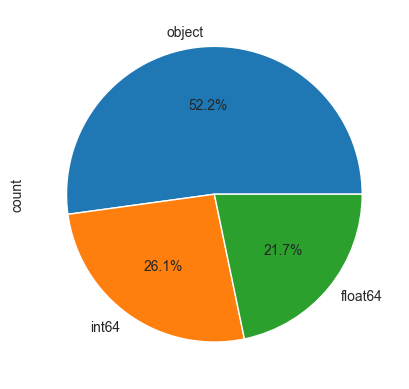

In [120]:
df.dtypes.value_counts().plot.pie(autopct='%1.1f%%')

On constate qu'il y a beaucoup de colonne de type object

In [121]:
df.duplicated().value_counts()

False    1296675
Name: count, dtype: int64

In [122]:
df_train.describe(include="all")

,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,city_pop,job,dob,trans_num,is_fraud
count,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06
unique,NaN,693,14,NaN,352,481,2,983,894,51,NaN,NaN,494,968,1296675,NaN
top,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,864 Reynolds Plains,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,8f7c8e4ab7f25875d753b422917c98c9,NaN
freq,NaN,4403,131659,NaN,26669,28794,709863,3123,5617,94876,NaN,NaN,9779,5636,1,NaN
mean,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,NaN,NaN,4.880067e+04,8.882444e+04,NaN,NaN,NaN,5.788652e-03
std,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,NaN,NaN,2.689322e+04,3.019564e+05,NaN,NaN,NaN,7.586269e-02
min,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,NaN,0.000000e+00
25%,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,NaN,0.000000e+00
50%,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,NaN,0.000000e+00
75%,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,NaN,NaN,7.204200e+04,2.032800e+04,NaN,NaN,NaN,0.000000e+00


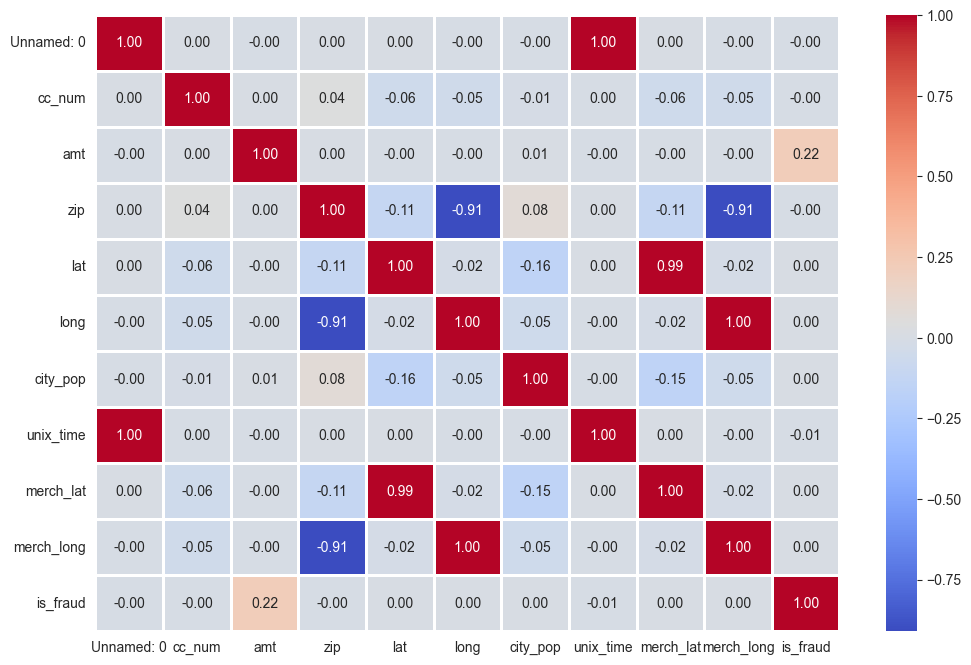

In [123]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
#kot = corr[(corr !=1.000) & ((corr >=0.4) | (corr <=(-0.2)))]
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

In [124]:
df.drop(["unix_time","merch_lat","merch_long","lat","long",'Unnamed: 0','trans_num','cc_num'], axis=1, inplace=True)

In [125]:
df_train.describe(include='all')

,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,city_pop,job,dob,trans_num,is_fraud
count,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06
unique,NaN,693,14,NaN,352,481,2,983,894,51,NaN,NaN,494,968,1296675,NaN
top,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,864 Reynolds Plains,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,8f7c8e4ab7f25875d753b422917c98c9,NaN
freq,NaN,4403,131659,NaN,26669,28794,709863,3123,5617,94876,NaN,NaN,9779,5636,1,NaN
mean,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,NaN,NaN,4.880067e+04,8.882444e+04,NaN,NaN,NaN,5.788652e-03
std,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,NaN,NaN,2.689322e+04,3.019564e+05,NaN,NaN,NaN,7.586269e-02
min,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,NaN,0.000000e+00
25%,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,NaN,0.000000e+00
50%,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,NaN,0.000000e+00
75%,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,NaN,NaN,7.204200e+04,2.032800e+04,NaN,NaN,NaN,0.000000e+00


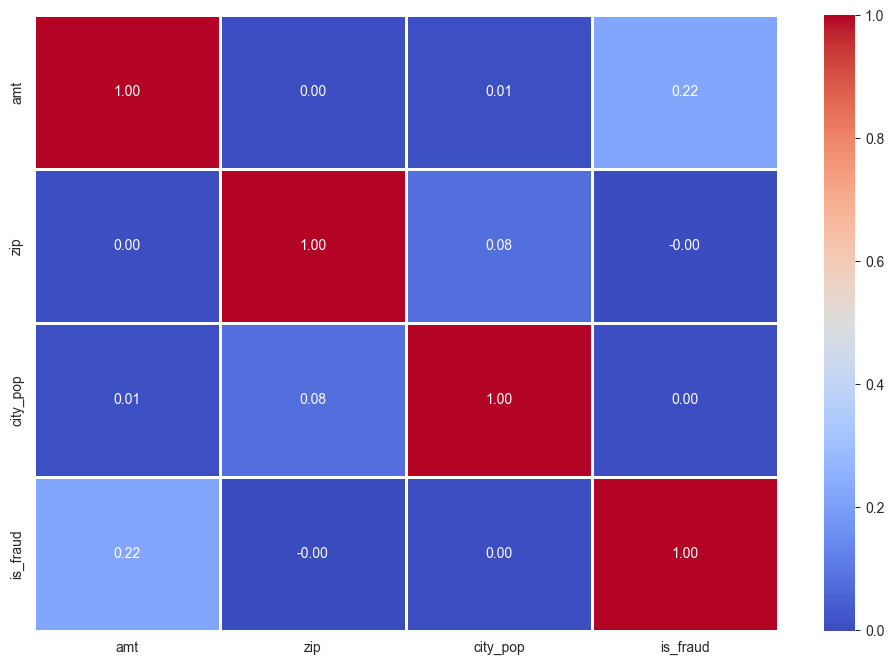

In [126]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

In [127]:
df.sample(5)

,trans_date_trans_time,merchant,category,amt,first,last,gender,street,city,state,zip,city_pop,job,dob,is_fraud
139084,2019-03-17 05:20:25,fraud_Auer-West,shopping_net,9.83,Jessica,Jordan,F,071 Wise Trace,Coleharbor,ND,58531,307,Make,1930-08-13,0
100854,2019-02-28 05:20:32,fraud_Jast Ltd,shopping_net,5.02,James,Reese,M,26975 Richardson Mills Apt. 402,Sontag,MS,39665,1196,"Librarian, academic",1958-06-11,0
1051177,2020-03-11 22:26:46,fraud_Pacocha-Weissnat,kids_pets,84.28,Susan,Shah,F,9016 Jordan Bypass Apt. 516,Cranks,KY,40820,581,"Psychologist, counselling",1967-02-04,0
1488,2019-01-01 16:19:15,"fraud_Roberts, Daniel and Macejkovic",kids_pets,77.21,Lisa,Mendez,F,44259 Beth Station Suite 215,Lahoma,OK,73754,1078,"Programme researcher, broadcasting/film/video",1952-07-06,0
1101505,2020-04-03 10:09:12,fraud_Huels-Hahn,gas_transport,61.30,Dylan,Garcia,M,923 Jordan Road,Afton,MN,55001,2916,Barrister's clerk,1935-06-29,0


job
Film/video editor             9779
Exhibition designer           9199
Naval architect               8684
Surveyor, land/geomatics      8680
Materials engineer            8270
                              ... 
Veterinary surgeon               8
Information officer              8
Contracting civil engineer       7
Ship broker                      7
Warehouse manager                7
Name: count, Length: 494, dtype: int64

# Pretraitement

In [128]:
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder
from datetime import datetime

In [134]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['age_at_transaction'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['age_at_transaction'] = df['age_at_transaction'].round(0).astype(int)
df['age_at_transaction']

0          31
1          41
2          57
3          52
4          33
           ..
1296670    59
1296671    41
1296672    53
1296673    40
1296674    25
Name: age_at_transaction, Length: 1296675, dtype: int64

<Axes: ylabel='Frequency'>

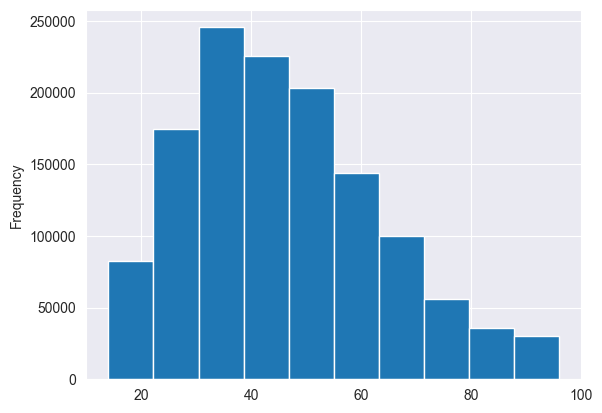

In [135]:
df['age_at_transaction'].plot(kind='hist')

In [140]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'first', 'last',
       'gender', 'street', 'city', 'state', 'zip', 'city_pop', 'job', 'dob',
       'is_fraud', 'age_at_transaction'],
      dtype='object')

In [ ]:
numeric_features = ["amt", "zip", "city_pop", "age_at_transaction"]
categorical_features_ord = ["Sex", "Embarked"]
categorical_features_non_ord = ["Sex", "Embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

categorical_non_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinay", OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat_ord", categorical_ord_transformer, categorical_features_ord),
        ("cat_non_ord", categorical_non_ord_transformer, categorical_features_non_ord),
    ],
    remainder="drop"
)

# Machine Learning

In [105]:
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC